<a href="https://colab.research.google.com/github/AlenMJohn82/Speech-emotion-recognition-using-transfomer/blob/master/mini_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def extract_all_features(path, max_length=100):
    data, sr = librosa.load(path, duration=2.5, offset=0.6)

    # Feature extraction
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr), ref=np.max)

    # Combine
    combined = np.vstack([mfcc, chroma, tonnetz, mel]).T  # (timesteps, features)

    # Pad/truncate all to max_length
    def pad_truncate(feat):
        if feat.shape[1] < max_length:
            return np.pad(feat, ((0, 0), (0, max_length - feat.shape[1])), mode='constant')
        else:
            return feat[:, :max_length]

    # Return all properly padded/truncated
    return (
        pad_truncate(mfcc),
        pad_truncate(chroma),
        pad_truncate(tonnetz),
        pad_truncate(mel),
        pad_truncate(combined.T)  # <== CAREFUL here
    )


# 2. Load dataset
dataset_path = "/content/drive/MyDrive/mini dataset/ravedss datset"  # ✅ Make sure path is correct
audio_files = glob.glob(os.path.join(dataset_path, "**/*.wav"), recursive=True)
print(f"Found {len(audio_files)} audio files.")

# 3. Extract features and labels
emotion_map = {
    '01': 0, '02': 1, '03': 2, '04': 3,
    '05': 4, '06': 5, '07': 6, '08': 7
}

X, y = [], []

for file in tqdm(audio_files, desc="Processing files"):
    try:
        emotion_code = os.path.basename(file).split('-')[2]
        mfcc, chroma, tonnetz, mel, combined = extract_all_features(file)
        X.append(combined)  # Only combined is stored for training
        y.append(emotion_map[emotion_code])
    except Exception as e:
        print(f"Skipped {file}: {str(e)}")


X = np.array(X)
y = np.array(y)
print(f"Extracted features: {X.shape}")
print(f"Extracted labels: {y.shape}")

# 4. Train/val split (removed test set)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.176, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")


Found 1440 audio files.


Processing files:   0%|          | 0/1440 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=862
  warnings.warn(
Processing files:  33%|███▎      | 472/1440 [05:13<10:51,  1.49it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=851
  warnings.warn(
Processing files:  50%|█████     | 721/1440 [07:52<07:22,  1.63it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=840
  warnings.warn(
Processing files:  51%|█████     | 733/1440 [08:00<09:00,  1.31it/s]/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=805
  warnings.warn(
Processing files:  52%|█████▏    | 747/1440 [08:08<06:39,  1.73it/s]/usr/local/lib/python3.11/dist-packages/librosa/co

Extracted features: (1440, 159, 100)
Extracted labels: (1440,)
Train: (1186, 159, 100), Validation: (254, 159, 100)


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

import torch.nn as nn
from torch.nn import TransformerEncoderLayer, TransformerEncoder



In [ ]:
# 5. Convert to tensors
X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(np.array(X_val), dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

# Assuming you have already split or loaded your X_test and y_test data,
# if not, make sure you define them like this:
# X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
# y_test = torch.tensor(y_test, dtype=torch.long)

# Example: If you haven't yet split the data:
# from sklearn.model_selection import train_test_split
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
# X_test = torch.tensor(X_test, dtype=torch.float32)
# y_test = torch.tensor(y_test, dtype=torch.long)

# 6. Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
import torch
import torch.nn as nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import DataLoader, TensorDataset

class EmotionTransformer(nn.Module):
    def __init__(self, input_dim=159, n_classes=8, d_model=128, nhead=4, num_layers=2, max_seq_len=100):
        super().__init__()
        # Define the embedding layer (converts input_dim to d_model)
        self.embedding = nn.Linear(input_dim, d_model)

        # Define dynamic positional encoding (adjusted for the max sequence length)
        self.pos_encoder = nn.Parameter(torch.randn(1, max_seq_len, d_model))  # Fixed max_seq_len

        # Define Transformer Encoder Layer
        encoder_layers = TransformerEncoderLayer(d_model, nhead, dropout=0.1)
        self.transformer = TransformerEncoder(encoder_layers, num_layers)

        # Final classifier layer (output layer)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # Check input shape: (batch_size, seq_length, input_dim)
        print(f"Input shape before embedding: {x.shape}")

        # Apply embedding to convert input_dim to d_model
        x = self.embedding(x)  # Shape: (batch_size, seq_length, d_model)
        print(f"Shape after embedding: {x.shape}")

        # Adjust positional encoding based on actual sequence length
        seq_len = x.size(1)
        pos_enc = self.pos_encoder[:, :seq_len, :]  # Slice to match the sequence length

        # Add positional encoding
        x = x + pos_enc
        print(f"Shape after adding positional encoding: {x.shape}")

        # Permute the tensor to (seq_length, batch_size, d_model) for transformer
        x = x.permute(1, 0, 2)
        print(f"Shape after permute: {x.shape}")

        # Pass through transformer
        x = self.transformer(x)
        print(f"Shape after transformer: {x.shape}")

        # Aggregate the output: take the mean across the sequence dimension (batch_size, d_model)
        x = x.mean(dim=0)  # Shape: (batch_size, d_model)
        print(f"Shape after mean aggregation: {x.shape}")

        # Final classification layer (output classes)
        return self.classifier(x)  # Shape: (batch_size, n_classes)

# Example Input Data (Ensure input data is of shape (batch_size, seq_length, input_dim))
# Let's simulate some input data
batch_size = 32
seq_length = 100
input_dim = 159  # Example input dimension

# Simulating random data for the example
X_train = torch.randn(batch_size, seq_length, input_dim)
y_train = torch.randint(0, 8, (batch_size,))  # Random labels for 8 classes

# Initialize the model
model = EmotionTransformer(input_dim=input_dim, d_model=128, n_classes=8)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop (using a smaller epoch count for testing)
for epoch in range(50):  # Testing with 3 epochs
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)  # Forward pass
        loss = criterion(outputs, batch_y)  # Calculate loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

    # Validation - for now, using the same data for validation to test the training process
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_train)
        val_acc = (val_outputs.argmax(dim=1) == y_train).float().mean()
    print(f"Epoch {epoch}: Val Acc={val_acc:.4f}")

# Evaluate the model on test data (same as training data for testing)
model.eval()
with torch.no_grad():
    y_pred = model(X_train).argmax(dim=1)
    test_acc = (y_pred == y_train).float().mean()
print(f"Test Accuracy: {test_acc:.4f}")



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Input shape before embedding: torch.Size([32, 100, 159])
Shape after embedding: torch.Size([32, 100, 128])
Shape after adding positional encoding: torch.Size([32, 100, 128])
Shape after permute: torch.Size([100, 32, 128])
Shape after transformer: torch.Size([100, 32, 128])
Shape after mean aggregation: torch.Size([32, 128])
Input shape before embedding: torch.Size([32, 100, 159])
Shape after embedding: torch.Size([32, 100, 128])
Shape after adding positional encoding: torch.Size([32, 100, 128])
Shape after permute: torch.Size([100, 32, 128])
Shape after transformer: torch.Size([100, 32, 128])
Shape after mean aggregation: torch.Size([32, 128])
Epoch 0: Val Acc=0.1250
Input shape before embedding: torch.Size([32, 100, 159])
Shape after embedding: torch.Size([32, 100, 128])
Shape after adding positional encoding: torch.Size([32, 100, 128])
Shape after permute: torch.Size([100, 32, 128])
Shape after transformer: torch.Size([100, 32, 128])
Shape after mean aggregation: torch.Size([32, 128]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1: Train Acc=0.1250, Val Acc=0.1875
Epoch 2: Train Acc=0.1875, Val Acc=0.1875
Epoch 3: Train Acc=0.1875, Val Acc=0.2188
Epoch 4: Train Acc=0.2188, Val Acc=0.1875
Epoch 5: Train Acc=0.1875, Val Acc=0.1875
Epoch 6: Train Acc=0.1875, Val Acc=0.1875
Epoch 7: Train Acc=0.1875, Val Acc=0.1875
Epoch 8: Train Acc=0.1875, Val Acc=0.1875
Epoch 9: Train Acc=0.1875, Val Acc=0.1875
Epoch 10: Train Acc=0.1875, Val Acc=0.1875
Epoch 11: Train Acc=0.1875, Val Acc=0.1875
Epoch 12: Train Acc=0.1875, Val Acc=0.2188
Epoch 13: Train Acc=0.2188, Val Acc=0.2500
Epoch 14: Train Acc=0.2188, Val Acc=0.3125
Epoch 15: Train Acc=0.3125, Val Acc=0.3125
Epoch 16: Train Acc=0.3125, Val Acc=0.3125
Epoch 17: Train Acc=0.3125, Val Acc=0.3125
Epoch 18: Train Acc=0.3125, Val Acc=0.3125
Epoch 19: Train Acc=0.2812, Val Acc=0.3125
Epoch 20: Train Acc=0.3125, Val Acc=0.3125
Epoch 21: Train Acc=0.3125, Val Acc=0.3125
Epoch 22: Train Acc=0.3125, Val Acc=0.3125
Epoch 23: Train Acc=0.3125, Val Acc=0.3438
Epoch 24: Train Acc=

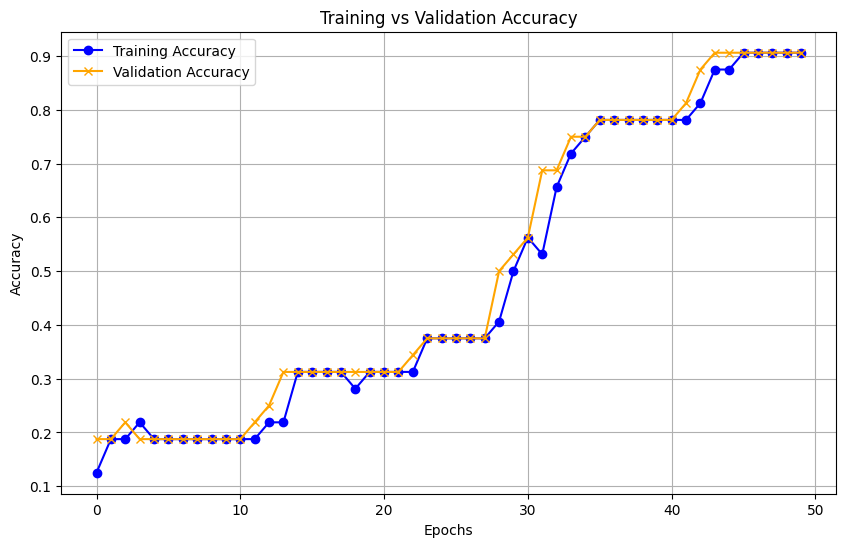

Final Test Accuracy: 0.9062


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import DataLoader, TensorDataset

# Define the EmotionTransformer model
class EmotionTransformer(nn.Module):
    def __init__(self, input_dim=159, n_classes=8, d_model=128, nhead=4, num_layers=2, max_seq_len=100):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, max_seq_len, d_model))  # Fixed max_seq_len
        encoder_layers = TransformerEncoderLayer(d_model, nhead, dropout=0.1)
        self.transformer = TransformerEncoder(encoder_layers, num_layers)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        x = self.embedding(x)
        seq_len = x.size(1)
        pos_enc = self.pos_encoder[:, :seq_len, :]  # Slice to match the sequence length
        x = x + pos_enc
        x = x.permute(1, 0, 2)  # Permute for transformer
        x = self.transformer(x)
        x = x.mean(dim=0)  # Aggregate output
        return self.classifier(x)

# Initialize the model
model = EmotionTransformer(input_dim=159, d_model=128, n_classes=8)

# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Simulate some input data for testing
batch_size = 32
seq_length = 100
input_dim = 159  # Example input dimension
X_train = torch.randn(batch_size, seq_length, input_dim)
y_train = torch.randint(0, 8, (batch_size,))

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# For plotting accuracies
train_accs = []  # List to store training accuracies
val_accs = []  # List to store validation accuracies

# Training loop (using a smaller epoch count for testing)
for epoch in range(50):  # Adjust epochs as needed
    model.train()
    correct_train = 0
    total_train = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)  # Forward pass
        loss = criterion(outputs, batch_y)  # Calculate loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights

        # Calculate training accuracy
        _, predicted_train = torch.max(outputs, 1)
        correct_train += (predicted_train == batch_y).sum().item()
        total_train += batch_y.size(0)

    # Store training accuracy for plotting
    train_acc = correct_train / total_train
    train_accs.append(train_acc)

    # Validation - using the same data for validation to test the training process
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_train)
        _, predicted_val = torch.max(val_outputs, 1)
        correct_val = (predicted_val == y_train).sum().item()
        val_acc = correct_val / y_train.size(0)
    val_accs.append(val_acc)

    # Print Epoch results
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

# Plotting the training and validation accuracies
plt.figure(figsize=(10, 6))
plt.plot(train_accs, label='Training Accuracy', color='blue', linestyle='-', marker='o')
plt.plot(val_accs, label='Validation Accuracy', color='orange', linestyle='-', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Final evaluation (same data as a placeholder)
model.eval()
with torch.no_grad():
    y_pred = model(X_train).argmax(dim=1)
    test_acc = (y_pred == y_train).float().mean()
print(f"Final Test Accuracy: {test_acc:.4f}")
